In [1]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# LBM Rain

In [3]:
rain = pd.read_csv('LBM_rain_2020.dat',sep=',')
rain.index = pd.to_datetime(rain['TIMESTAMP'])
rain.index.name = None

In [5]:
means = {}
means['TIMESTAMP'] = []
means['precip'] = []
date_end = rain.index[-1]
current_date = datetime(2021,3,29)
current_date = current_date.replace(minute=30)

while current_date <= date_end:
    means['TIMESTAMP'].append(current_date.replace(minute=0) + timedelta(hours=1))

    next_date = current_date + timedelta(hours=1)
    idxs = np.array(list(map(lambda x: current_date <= x < next_date, rain.index)))

    df = rain.loc[idxs,'PL01_mm_Tot']
    if len(df) >= 6:
        means['precip'].append(np.sum(df))
    else:
        means['precip'].append(np.nan)

    current_date = next_date

In [6]:
new = pd.DataFrame(means)
new.index = pd.to_datetime(new['TIMESTAMP'])
new.index.name = None
new['year'] = new.index.year
new['month'] = new.index.month
new['day'] = new.index.day
new['hour'] = new.index.hour

In [7]:
new.head()

,TIMESTAMP,precip,year,month,day,hour
2021-03-29 01:00:00,2021-03-29 01:00:00,0.0,2021,3,29,1
2021-03-29 02:00:00,2021-03-29 02:00:00,0.0,2021,3,29,2
2021-03-29 03:00:00,2021-03-29 03:00:00,0.0,2021,3,29,3
2021-03-29 04:00:00,2021-03-29 04:00:00,0.0,2021,3,29,4
2021-03-29 05:00:00,2021-03-29 05:00:00,0.0,2021,3,29,5


In [8]:
new.to_csv('labmim_2021_rain.dat',na_rep='nan',sep=';',index=False)

# LBM Lenta

In [9]:
bruto_2020 = pd.read_csv('LBM_lenta_2020.dat', sep=',', parse_dates=True, infer_datetime_format=True)
bruto_2020.index = pd.to_datetime(bruto_2020['TIMESTAMP'])
bruto_2020.drop(columns=['TIMESTAMP', 'RECORD', 'rtime', 'batt_volt', 'panel_temp', 'CM3Up_mv_Avg', 'CG3Up_mv_Avg', 'CM3Dn_mv_Avg', 'CG3Dn_mv_Avg', 'NRLite_Wm2_Avg', 'CMP21_Avg', 'PAR_Den_Avg'], inplace=True)
bruto_2020.index.name = None

In [11]:
bruto_2020['u'] = -bruto_2020['WS_WXT_Avg']*np.sin(np.radians(bruto_2020['WD_WXT_Avg']))
bruto_2020['v'] = -bruto_2020['WS_WXT_Avg']*np.cos(np.radians(bruto_2020['WD_WXT_Avg']))

means = {}
for col in bruto_2020.columns:
    bruto_2020.loc[(bruto_2020[col] < -900),col] = np.nan
    means[col] = []
means['TIMESTAMP'] = []

date_end = bruto_2020.index[-1]
current_date = datetime(2021,3,29)
current_date = current_date.replace(minute=30)

In [12]:
while current_date <= date_end:
        means['TIMESTAMP'].append(current_date.replace(minute=0) + timedelta(hours=1))

        next_date = current_date + timedelta(hours=1)
        idxs = np.array(list(map(lambda x: current_date <= x < next_date, bruto_2020.index)))

        for col in bruto_2020.columns:
            df = bruto_2020.loc[idxs,col]
            if len(df) >= 6:
                if col == 'WD_WXT_Avg':
                    alfa = np.arctan2(np.nanmean(bruto_2020.loc[idxs,'v']), np.nanmean(bruto_2020.loc[idxs,'u']))
                    means[col].append(np.fmod(3*(np.pi/2) - alfa, 2*np.pi)*(180/np.pi))
                else:
                    means[col].append(np.nanmean(df))
            else:
                means[col].append(np.nan)

        current_date = next_date

In [13]:
new = pd.DataFrame(means)
new.index = pd.to_datetime(new['TIMESTAMP'])
new.index.name = None

In [14]:
new['year'] = new.index.year
new['month'] = new.index.month
new['day'] = new.index.day
new['hour'] = new.index.hour

In [16]:
new.head()

,CNR1TK_Avg,CM3Up_Wm2_Avg,CG3Up_Wm2_Avg,CM3Dn_Wm2_Avg,CG3Dn_Wm2_Avg,CNR1TC_Avg,CG3Up_Wm2Cr_Avg,CG3Dn_Wm2Cr_Avg,Net_Wm2_Avg,CMP21_Wm2_Avg,...,Temp_WXT_Avg,RH_WXT_Avg,Pmb_WXT,u,v,TIMESTAMP,year,month,day,hour
2021-03-29 01:00:00,297.575000,-2.616167,-56.960000,3.659833,6.796500,24.435833,387.725000,451.475000,-70.031667,-2.854083,...,26.571667,69.332500,1008.625000,-0.033189,0.337461,2021-03-29 01:00:00,2021,3,29,1
2021-03-29 02:00:00,296.508333,-2.440583,-52.415833,3.779667,8.574750,23.368333,385.908333,446.900000,-67.212500,-2.664917,...,25.670000,73.827500,1008.116667,0.085346,0.074507,2021-03-29 02:00:00,2021,3,29,2
2021-03-29 03:00:00,296.250000,-1.315000,-40.202500,3.953000,9.113333,23.108333,396.566667,445.891667,-54.585000,-1.605667,...,25.315000,75.673333,1007.758333,0.045864,0.276223,2021-03-29 03:00:00,2021,3,29,3
2021-03-29 04:00:00,297.300000,-0.361417,-25.630833,2.975083,6.897417,24.148333,417.300000,449.833333,-35.865833,-0.697917,...,26.264167,72.528333,1007.691667,-0.116662,0.769085,2021-03-29 04:00:00,2021,3,29,4
2021-03-29 05:00:00,297.541667,-1.574750,-46.586667,2.742917,4.109917,24.398333,397.866667,448.550000,-55.013333,-1.954417,...,26.394167,71.232500,1007.925000,-0.287542,0.897559,2021-03-29 05:00:00,2021,3,29,5


In [17]:
new.to_csv('labmim_2021.dat',na_rep='nan',sep=';',index=False)

In [11]:
ls

'balanco de radiacao.ipynb'   labmim_completo_2021.dat
 balanco_media_horaria.dat    labmim_completo_controle2020.dat
 balanco_media_mensal.dat     labmim-merge-2020-2021.ipynb
 files.py                     LBM_lenta_2020_03.dat
 graficos1_UFBA_v7.py         LBM_lenta_2020_04.dat
 graficos2_UFBA_v3.PY         LBM_lenta_2020.dat
 labmim_2020_2021_0.dat       LBM_rain_2020.dat
 labmim_2020_2021.dat         old/
 labmim_bruto.dat             process-bruto2horario.ipynb


# Merge all

In [ ]:
#new = rain total

In [18]:
header_lab = ['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS', 'u', 'v', 'precip', 'Sw_dw', 'Sw_up', 'Lw_dw', 'Lw_up', 'Sw_dif', 'Sw_par', 'RH_WXT', 'Temp_WXT', 'Net_CNR1', 'Net_NRLite']
header_teo = ['oc_topo', 'decl_rad', 'elev_solar', 'ang_hor', 'ang_zen', 'ang_hor_por', 'nascer_h', 'por_h', 'ast_h', 'fc']
header = header_lab + header_teo

In [19]:
lab2020 = pd.read_csv('labmim_2021.dat', sep=';')
lab2020.index = pd.to_datetime(lab2020[['year', 'month', 'day', 'hour']])

In [20]:
lab2020.rename(columns = {'CM3Up_Wm2_Avg':'Sw_dw',
    'CM3Dn_Wm2_Avg':'Sw_up',
    'CG3Up_Wm2Cr_Avg':'Lw_dw',
    'CG3Dn_Wm2Cr_Avg':'Lw_up',
    'CMP21_Wm2_Avg':'Sw_dif',
    'RH_WXT_Avg':'RH_WXT',
    'Pmb_WXT':'pressure',
    'Temp_WXT_Avg':'Temp_WXT',
    'WS_WXT_Avg':'WS',
    'WD_WXT_Avg':'WD',
    'Temp1_Avg':'T',
    'RH1_Avg':'ur',
    'PAR_Wm2_Avg':'Sw_par',
    'Net_Wm2_Avg':'Net_CNR1',
    'NRLite_Wm2Cr_Avg':'Net_NRLite'
    }, inplace=True)

In [21]:
new = pd.read_csv('labmim_2021_rain.dat', sep=';')
new.index = pd.to_datetime(new[['year', 'month', 'day', 'hour']])

In [22]:
new.head()

,TIMESTAMP,precip,year,month,day,hour
2021-03-29 01:00:00,2021-03-29 01:00:00,0.0,2021,3,29,1
2021-03-29 02:00:00,2021-03-29 02:00:00,0.0,2021,3,29,2
2021-03-29 03:00:00,2021-03-29 03:00:00,0.0,2021,3,29,3
2021-03-29 04:00:00,2021-03-29 04:00:00,0.0,2021,3,29,4
2021-03-29 05:00:00,2021-03-29 05:00:00,0.0,2021,3,29,5


In [23]:
lab2020['Td'] = np.nan
lab2020.loc[lab2020.index[0]:lab2020.index[-1],'precip'] = new[lab2020.index[0]:lab2020.index[-1]]['precip']

In [24]:
lab2020 = lab2020[header_lab]

In [25]:
lab2020.columns

Index(['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS',
       'u', 'v', 'precip', 'Sw_dw', 'Sw_up', 'Lw_dw', 'Lw_up', 'Sw_dif',
       'Sw_par', 'RH_WXT', 'Temp_WXT', 'Net_CNR1', 'Net_NRLite'],
      dtype='object')

In [26]:
lab2021 = pd.read_csv('labmim_completo_total.dat', sep=';')
lab2021.index = pd.to_datetime(lab2021[['year', 'month', 'day', 'hour']])

In [68]:
lab2021.loc[new.index[0]:new.index[-1],'precip'] = new['precip']

In [27]:
final = pd.merge_ordered(lab2020,lab2021)

In [28]:
final.index = pd.to_datetime(final[['year', 'month', 'day', 'hour']])

In [29]:
final.to_csv('labmim_completo_total_2021.dat',na_rep='nan',sep=';',index=False)

# Teste

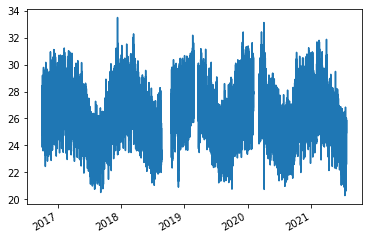

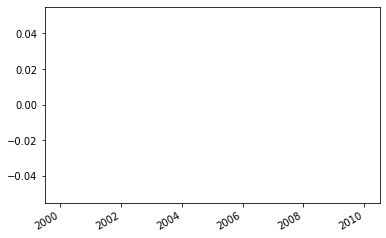

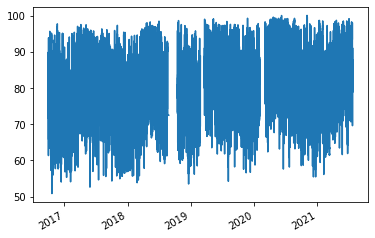

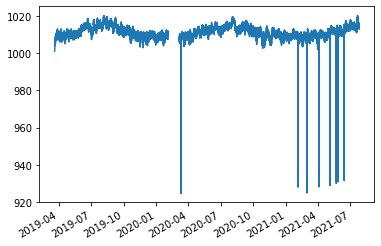

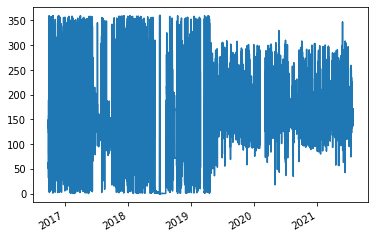

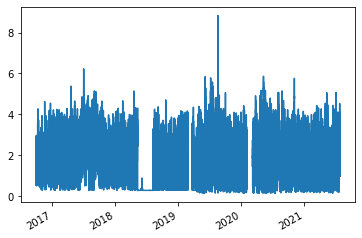

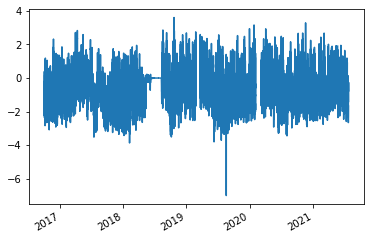

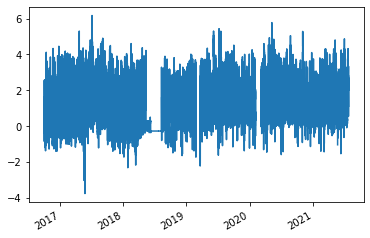

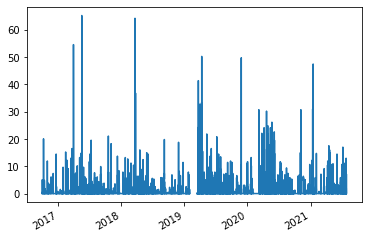

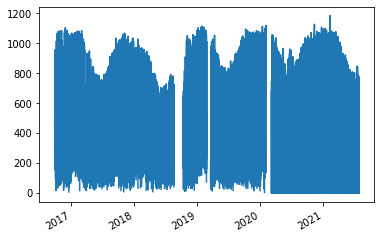

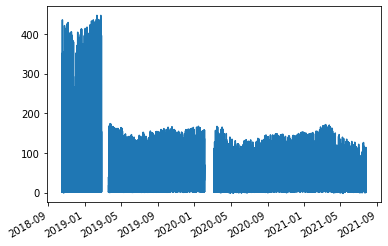

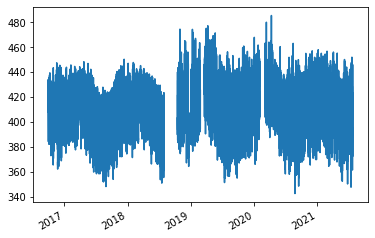

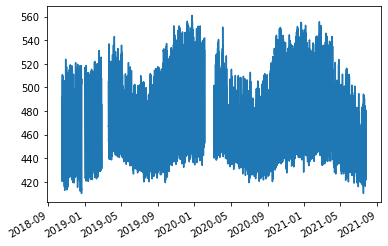

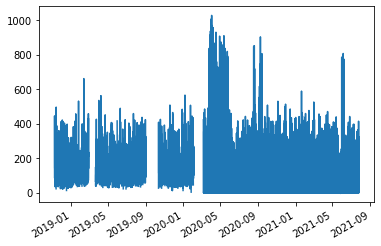

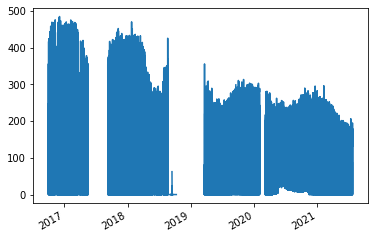

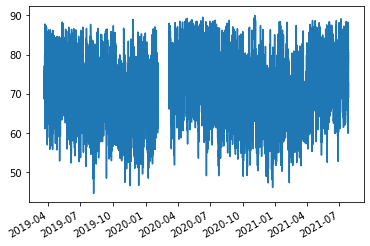

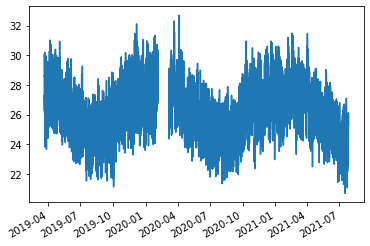

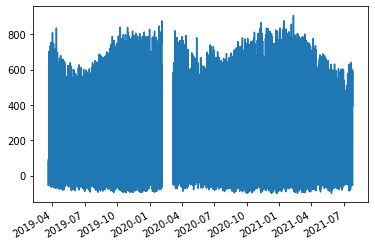

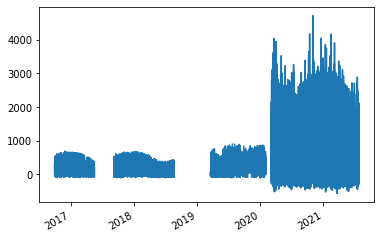

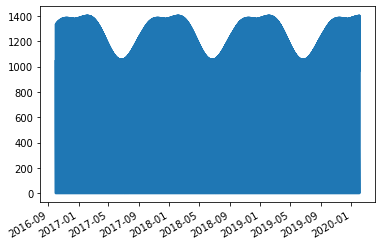

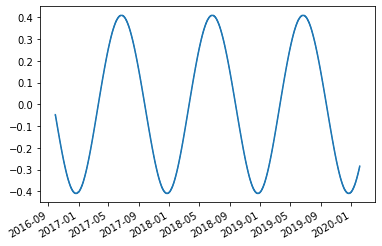

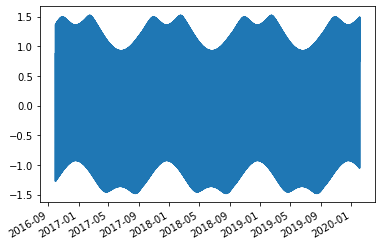

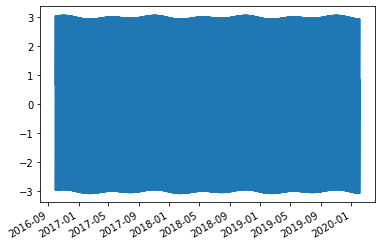

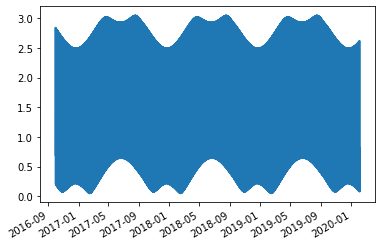

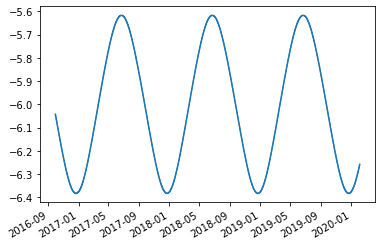

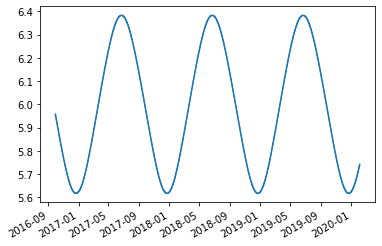

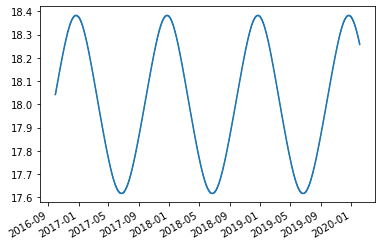

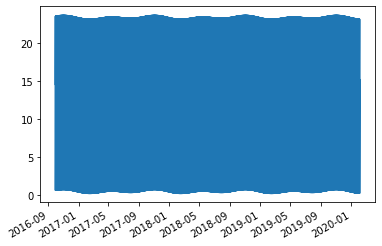

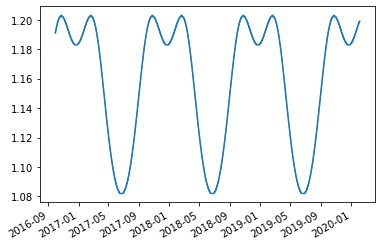

In [30]:
for col in final:
    if col not in ['year', 'month', 'day', 'hour']:
        final[col].plot(title=col)
        plt.show()
        plt.close()